In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
from preprocessing import AudioFeatureProcessor

/usr/local/Caskroom/miniconda/base/envs/music-explorer/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/spotify_tracks_raw.csv')
print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded: (800, 14)
Columns: ['track_id', 'track_name', 'artist_name', 'genre', 'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'loudness', 'preview_url']


In [3]:
processor = AudioFeatureProcessor()
features_scaled = processor.preprocess_features(df)
print(f"Feature matrix shape: {features_scaled.shape}")
print(f"Standardization validation: μ={features_scaled.mean():.3f}, σ={features_scaled.std():.3f}")

Feature matrix shape: (800, 9)
Standardization validation: μ=0.000, σ=1.000


In [5]:
embedding = processor.apply_umap(features_scaled)
quality_metrics = processor.embedding_quality_metrics(features_scaled, embedding)
print(f"Embedding shape: {embedding.shape}")
print(f"Distance correlation: {quality_metrics['distance_correlation']:.3f}")
print(f"Statistical significance: p={quality_metrics['p_value']:.3e}")

/usr/local/Caskroom/miniconda/base/envs/music-explorer/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding shape: (800, 2)
Distance correlation: 0.510
Statistical significance: p=0.000e+00


In [6]:
df['x'] = embedding[:, 0]
df['y'] = embedding[:, 1]
df.to_csv('../data/spotify_tracks_embedded.csv', index=False)
print(f"Coordinates integrated: {df[['x', 'y']].describe()}")
print("Phase 2 dataset saved: spotify_tracks_embedded.csv")

Coordinates integrated:                 x           y
count  800.000000  800.000000
mean     7.112507    8.058122
std      1.729487    1.611431
min      3.809205    4.721171
25%      5.612777    6.784931
50%      7.306912    8.077687
75%      8.570431    9.344337
max     10.343642   11.042665
Phase 2 dataset saved: spotify_tracks_embedded.csv


In [8]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])

  Using cached plotly-6.3.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.5.0-py3-none-any.whl.metadata (11 kB)
Using cached plotly-6.3.0-py3-none-any.whl (9.8 MB)
Using cached narwhals-2.5.0-py3-none-any.whl (407 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


0

In [9]:
import plotly.express as px

fig = px.scatter(
    df, x='x', y='y', 
    color='genre',
    hover_data=['track_name', 'artist_name', 'energy', 'danceability'],
    title='Audio Feature Space: UMAP Embedding',
    width=800, height=600
)

fig.update_layout(
    xaxis_title="UMAP Dimension 1",
    yaxis_title="UMAP Dimension 2"
)

fig.show()
print("Phase 2 complete: 2D embedding visualization generated")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [10]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat>=4.2.0"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [nbformat]6/7 [nbformat]


0

In [13]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 4.7 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 3.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 4.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn]m8/9 [seaborn]ib]


0

Matplotlib is building the font cache; this may take a moment.


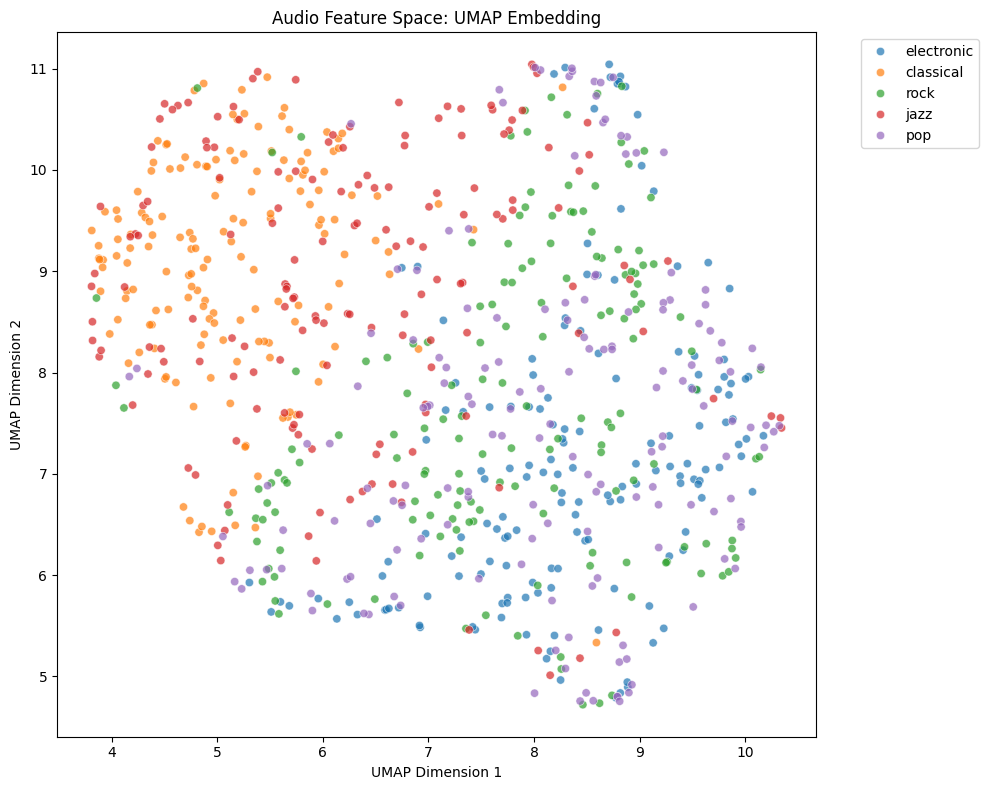

Phase 2 complete: 2D embedding visualization generated


In [14]:
# Static matplotlib visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='x', y='y', hue='genre', alpha=0.7)
plt.title('Audio Feature Space: UMAP Embedding')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Phase 2 complete: 2D embedding visualization generated")